# Predictive maintenance model

**Tasks**: 
1. End-to-End Pipeline: Write a Python script to generate the synthetic imbalanced dataset  and build an end-to-end Scikit-Learn Pipeline. The pipeline should handle scaling, outlier  treatment, and model training. 
2. Model Selection & Tuning: Train two different classification models. Implement a  strategy to handle the severe class imbalance (e.g., SMOTE, class weights, or custom  sampling). 
3. Evaluation: Evaluate the model. Do not use Accuracy. Use metrics appropriate for highly  imbalanced datasets. 
4. The "Human" Element (Technical Memo): Write a brief markdown memo (max 300  words) inside your repo explaining: 
○ Why you chose your specific evaluation metric over others (e.g., ROC-AUC vs. PR AUC). 
○ If the business cost of a False Negative (missing a machine failure) is 100x higher  than a False Positive (unnecessary maintenance check), how would you  mathematically adjust your model's decision threshold in production? Show the code  snippet for this adjustment. 


# Step 0 

In [36]:
# ==========================
# Basic Libraries
# ==========================

import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Dataset Generation
from sklearn.datasets import make_classification

# Train Test Split
from sklearn.model_selection import train_test_split

# Metrics
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score
)

# Ignore Warnings
import warnings
warnings.filterwarnings("ignore")

# Reproducibility
RANDOM_STATE = 42

print("Libraries imported successfully!")

Libraries imported successfully!


In [37]:
import sklearn
import imblearn

print("Scikit-Learn Version :", sklearn.__version__)
print("Imbalanced-Learn Version :", imblearn.__version__)

Scikit-Learn Version : 1.7.2
Imbalanced-Learn Version : 0.14.1


# Step 1: Synthetic Data Generation

In [38]:
# ==========================
# Generate Synthetic Dataset
# ==========================

X, y = make_classification(
    n_samples=100000,      # Total records
    n_features=20,         # Total sensor features
    n_informative=12,      # Useful features
    n_redundant=4,         # Correlated features
    n_repeated=0,
    n_classes=2,
    weights=[0.995, 0.005],  # 99.5% healthy, 0.5% failures
    flip_y=0,
    class_sep=1.0,
    random_state=RANDOM_STATE
)

print("Dataset Created Successfully!")
print("Shape of X:", X.shape)
print("Shape of y:", y.shape)

Dataset Created Successfully!
Shape of X: (100000, 20)
Shape of y: (100000,)


## Convert to DataFrame

In [39]:
# Create feature names

feature_names = [f"sensor_{i}" for i in range(1, 21)]

# Convert to DataFrame

df = pd.DataFrame(X, columns=feature_names)

# Add target column

df["failure"] = y

df.head()

,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,sensor_6,sensor_7,sensor_8,sensor_9,sensor_10,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,failure
0,-1.496596,3.598478,0.420355,-2.517875,-1.723906,-1.303456,4.360783,-0.736260,-1.013352,0.208285,...,-0.282840,3.471501,-0.752729,0.176620,3.571725,-0.004893,0.253209,-0.157769,0.561575,0
1,1.588427,0.021563,1.987999,0.814732,-1.959825,-1.203193,4.744014,-0.345622,3.169400,-4.283567,...,1.509545,0.646360,-1.167268,2.094629,0.930662,1.704498,0.044369,0.546866,-0.371378,0
2,1.248128,-0.350940,3.173332,4.828474,1.305101,0.508890,-1.153885,0.504817,2.421157,-0.173273,...,-0.551409,-2.552789,0.704865,0.934762,2.431484,1.189463,0.614756,0.949317,-3.506018,0
3,-5.018779,0.158361,-8.364981,-2.839102,-0.086872,-2.209352,4.211704,1.075300,-0.768315,2.954403,...,-0.522392,0.286686,0.813336,1.691189,4.166067,0.226361,0.270255,-1.552222,0.256674,0
4,1.839451,3.170041,-4.940358,-0.589623,1.255178,-4.591562,3.843878,0.676352,-2.028814,-0.908512,...,-0.538504,-0.623660,0.816275,-1.582429,-1.558232,2.071239,-0.100129,-1.241579,3.721558,0


## Basic Dataset Inspection

In [40]:
print("Dataset Shape:", df.shape)

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum().sum())

Dataset Shape: (100000, 21)

Data Types:
sensor_1     float64
sensor_2     float64
sensor_3     float64
sensor_4     float64
sensor_5     float64
sensor_6     float64
sensor_7     float64
sensor_8     float64
sensor_9     float64
sensor_10    float64
sensor_11    float64
sensor_12    float64
sensor_13    float64
sensor_14    float64
sensor_15    float64
sensor_16    float64
sensor_17    float64
sensor_18    float64
sensor_19    float64
sensor_20    float64
failure        int64
dtype: object

Missing Values:
0


In [41]:
## Target Distribution Analysis

In [42]:
failure_counts = df["failure"].value_counts()

print(failure_counts)

print("\nPercentage Distribution")

print(
    df["failure"]
    .value_counts(normalize=True)
    .mul(100)
    .round(3)
)

failure
0    99500
1      500
Name: count, dtype: int64

Percentage Distribution
failure
0    99.5
1     0.5
Name: proportion, dtype: float64


## Visualize Class Imbalance

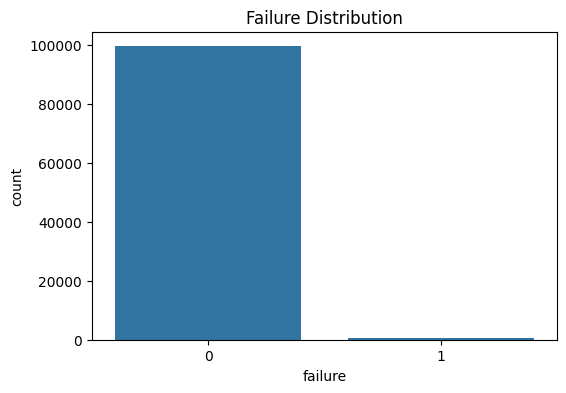

In [43]:
plt.figure(figsize=(6,4))

sns.countplot(
    x="failure",
    data=df
)

plt.title("Failure Distribution")
plt.show()

In [44]:
summary = pd.DataFrame({
    "Count": df["failure"].value_counts(),
    "Percentage": (
        df["failure"]
        .value_counts(normalize=True)
        * 100
    )
})

summary

,Count,Percentage
failure,,
0,99500,99.5
1,500,0.5


#  Step 2 Data Quality & Feature Understanding

In [45]:
# =====================================
# Dataset Overview
# =====================================

print("Dataset Shape:", df.shape)

print("\nFirst 5 Rows")
display(df.head())

print("\nLast 5 Rows")
display(df.tail())

Dataset Shape: (100000, 21)

First 5 Rows


,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,sensor_6,sensor_7,sensor_8,sensor_9,sensor_10,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,failure
0,-1.496596,3.598478,0.420355,-2.517875,-1.723906,-1.303456,4.360783,-0.736260,-1.013352,0.208285,...,-0.282840,3.471501,-0.752729,0.176620,3.571725,-0.004893,0.253209,-0.157769,0.561575,0
1,1.588427,0.021563,1.987999,0.814732,-1.959825,-1.203193,4.744014,-0.345622,3.169400,-4.283567,...,1.509545,0.646360,-1.167268,2.094629,0.930662,1.704498,0.044369,0.546866,-0.371378,0
2,1.248128,-0.350940,3.173332,4.828474,1.305101,0.508890,-1.153885,0.504817,2.421157,-0.173273,...,-0.551409,-2.552789,0.704865,0.934762,2.431484,1.189463,0.614756,0.949317,-3.506018,0
3,-5.018779,0.158361,-8.364981,-2.839102,-0.086872,-2.209352,4.211704,1.075300,-0.768315,2.954403,...,-0.522392,0.286686,0.813336,1.691189,4.166067,0.226361,0.270255,-1.552222,0.256674,0
4,1.839451,3.170041,-4.940358,-0.589623,1.255178,-4.591562,3.843878,0.676352,-2.028814,-0.908512,...,-0.538504,-0.623660,0.816275,-1.582429,-1.558232,2.071239,-0.100129,-1.241579,3.721558,0



Last 5 Rows


,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,sensor_6,sensor_7,sensor_8,sensor_9,sensor_10,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,failure
99995,1.180774,-0.841339,-0.220068,2.417551,0.296976,-0.023630,0.980915,-0.672984,4.298990,0.658796,...,1.679654,-2.559997,-0.763410,-1.052870,0.099201,-1.131702,1.685694,0.534932,0.399665,0
99996,-2.781815,-1.395264,-3.244864,-1.436254,0.204517,0.177964,-0.650234,-0.591805,2.806029,-2.278125,...,-2.488394,-0.755422,0.675998,1.345430,2.246015,-2.210923,-0.566213,2.055308,1.475957,0
99997,1.597075,-2.524750,4.840017,4.173886,4.554172,3.502890,-9.399917,0.718485,0.480154,0.803376,...,-0.794031,-2.479279,-1.391235,0.397393,-0.893823,-2.742552,-0.334082,0.433615,-3.270293,0
99998,-1.893211,-0.107179,-1.938034,-3.037706,-2.284826,-1.092923,4.283507,-1.537468,0.882543,-1.865636,...,-1.186113,1.840459,-0.467173,2.252445,3.600390,-1.752075,1.360365,0.929137,1.854892,0
99999,2.031868,-0.954556,4.134930,2.330958,-2.742300,-1.760499,5.138447,-0.109069,3.075703,-1.968546,...,0.334335,0.081804,0.529055,2.187067,2.725906,-2.275366,-1.868499,0.028704,0.207628,0


In [46]:
# =====================================
# Data Types
# =====================================

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 21 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   sensor_1   100000 non-null  float64
 1   sensor_2   100000 non-null  float64
 2   sensor_3   100000 non-null  float64
 3   sensor_4   100000 non-null  float64
 4   sensor_5   100000 non-null  float64
 5   sensor_6   100000 non-null  float64
 6   sensor_7   100000 non-null  float64
 7   sensor_8   100000 non-null  float64
 8   sensor_9   100000 non-null  float64
 9   sensor_10  100000 non-null  float64
 10  sensor_11  100000 non-null  float64
 11  sensor_12  100000 non-null  float64
 12  sensor_13  100000 non-null  float64
 13  sensor_14  100000 non-null  float64
 14  sensor_15  100000 non-null  float64
 15  sensor_16  100000 non-null  float64
 16  sensor_17  100000 non-null  float64
 17  sensor_18  100000 non-null  float64
 18  sensor_19  100000 non-null  float64
 19  sensor_20  100000 non-nu

In [47]:
# =====================================
# Missing Values
# =====================================

missing_values = df.isnull().sum()

missing_summary = pd.DataFrame({
    "Missing Count": missing_values,
    "Missing Percentage": (
        missing_values / len(df)
    ) * 100
})

missing_summary.sort_values(
    by="Missing Count",
    ascending=False
).head()

,Missing Count,Missing Percentage
sensor_1,0,0.0
sensor_12,0,0.0
sensor_20,0,0.0
sensor_19,0,0.0
sensor_18,0,0.0


In [48]:
# =====================================
# Duplicate Records
# =====================================

duplicate_count = df.duplicated().sum()

print(f"Duplicate Rows: {duplicate_count}")

Duplicate Rows: 0


In [49]:
# =====================================
# Statistical Summary
# =====================================

df.describe().T

,count,mean,std,min,25%,50%,75%,max
sensor_1,100000.0,-0.991508,2.090803,-9.875490,-2.396188,-0.993152,0.418711,8.445506
sensor_2,100000.0,-0.014308,2.029033,-7.703602,-1.440864,-0.186071,1.277902,9.281154
sensor_3,100000.0,-0.252238,4.079847,-18.283635,-2.982695,-0.270194,2.454941,16.956622
sensor_4,100000.0,0.018099,2.358058,-10.573252,-1.604444,-0.030639,1.590229,10.913781
sensor_5,100000.0,0.003459,2.133292,-8.983124,-1.452096,0.007108,1.464243,9.145386
sensor_6,100000.0,0.004179,1.976994,-7.117881,-1.384114,-0.101801,1.304767,8.131193
sensor_7,100000.0,0.295008,4.847301,-21.256907,-3.029358,0.189794,3.536164,22.974668
sensor_8,100000.0,-0.005389,0.995943,-4.419923,-0.676870,-0.008118,0.661631,4.386935
sensor_9,100000.0,1.006982,2.067735,-7.923043,-0.388777,1.006162,2.402583,9.926133
sensor_10,100000.0,0.003690,2.265518,-8.734117,-1.554642,-0.009862,1.530399,9.777657


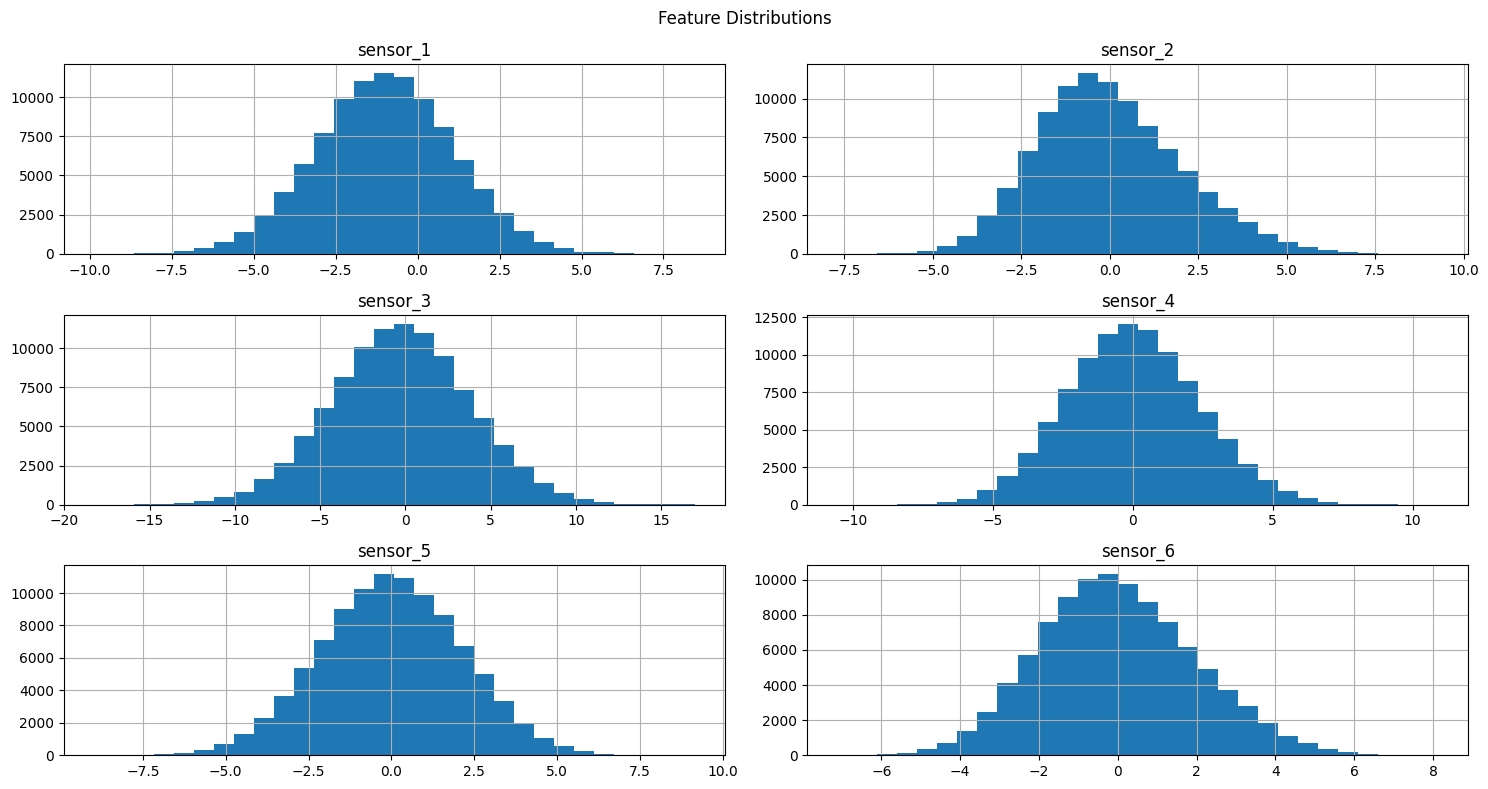

In [50]:
# =====================================
# Feature Distributions
# =====================================

selected_features = feature_names[:6] # inspect the first 6.

df[selected_features].hist(
    figsize=(15,8),
    bins=30
)

plt.suptitle("Feature Distributions")
plt.tight_layout()
plt.show()

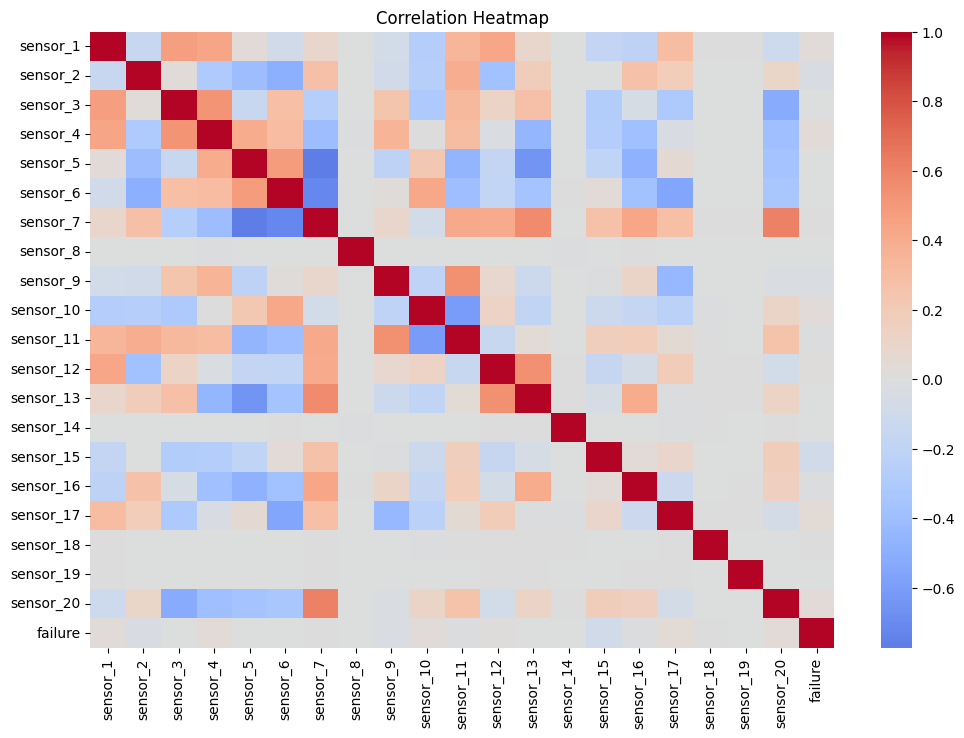

In [51]:
# =====================================
# Correlation Matrix
# =====================================

plt.figure(figsize=(12,8))

corr_matrix = df.corr()

sns.heatmap(
    corr_matrix,
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Heatmap")
plt.show()

**Correlation analysis helps identify redundant features and understand feature relationships. Since the synthetic dataset was generated with redundant variables, I expected some correlated features and verified their presence.**

In [52]:
# =====================================
# Compare Healthy vs Failure
# =====================================

target_summary = df.groupby("failure").mean()

target_summary.head()

,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,sensor_6,sensor_7,sensor_8,sensor_9,sensor_10,sensor_11,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20
failure,,,,,,,,,,,,,,,,,,,,
0,-0.995662,-0.009448,-0.251759,0.012901,0.003393,0.003993,0.293922,-0.005104,1.011527,-0.001142,0.435462,-0.179824,-0.001392,-0.000164,0.995843,-0.007348,-1.008225,-0.000374,-0.000812,-0.004168
1,-0.164856,-0.981498,-0.347545,1.052426,0.016555,0.041172,0.511037,-0.062164,0.102541,0.965353,-0.178541,0.285090,-0.011676,-0.024054,-1.026389,-0.197056,0.029452,0.092144,-0.057590,0.988394


# Step 3 Outlier Analysis

In [53]:
# =====================================
# Outlier Analysis using IQR
# =====================================

outlier_summary = []

for col in feature_names:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = (
        (df[col] < lower_bound) |
        (df[col] > upper_bound)
    ).sum()

    percentage = (outliers / len(df)) * 100

    outlier_summary.append(
        [col, outliers, round(percentage, 2)]
    )

outlier_df = pd.DataFrame(
    outlier_summary,
    columns=[
        "Feature",
        "Outlier Count",
        "Outlier Percentage"
    ]
)

outlier_df.sort_values(
    by="Outlier Percentage",
    ascending=False
)

,Feature,Outlier Count,Outlier Percentage
14,sensor_15,932,0.93
1,sensor_2,874,0.87
2,sensor_3,859,0.86
17,sensor_18,746,0.75
7,sensor_8,734,0.73
13,sensor_14,721,0.72
0,sensor_1,714,0.71
18,sensor_19,712,0.71
11,sensor_12,714,0.71
16,sensor_17,703,0.70


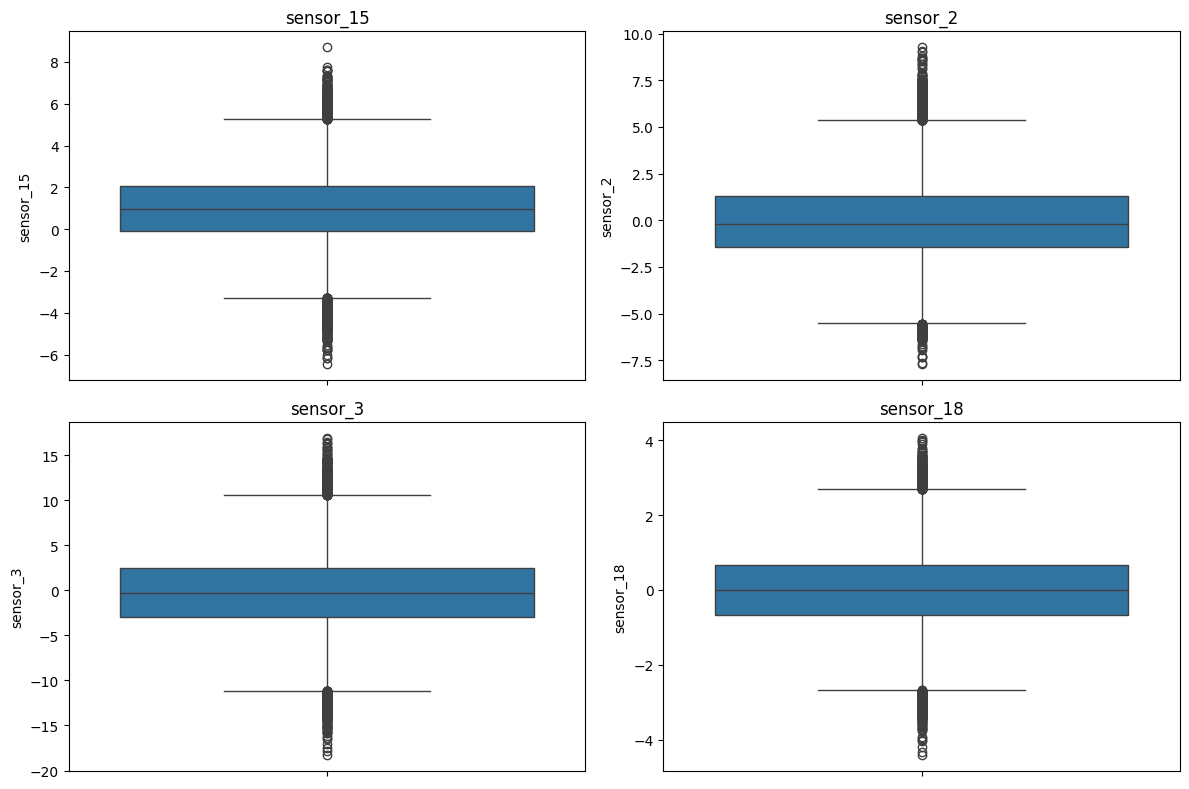

In [54]:
top_features = (
    outlier_df
    .sort_values(
        by="Outlier Percentage",
        ascending=False
    )
    .head(4)["Feature"]
)

plt.figure(figsize=(12,8))

for i, feature in enumerate(top_features, 1):

    plt.subplot(2, 2, i)

    sns.boxplot(
        y=df[feature]
    )

    plt.title(feature)

plt.tight_layout()
plt.show()

In [55]:
from sklearn.base import BaseEstimator, TransformerMixin

class IQRCapper(BaseEstimator, TransformerMixin):

    def fit(self, X, y=None):

        self.lower_bounds_ = {}
        self.upper_bounds_ = {}

        for col in X.columns:

            Q1 = X[col].quantile(0.25)
            Q3 = X[col].quantile(0.75)

            IQR = Q3 - Q1

            self.lower_bounds_[col] = Q1 - 1.5 * IQR
            self.upper_bounds_[col] = Q3 + 1.5 * IQR

        return self

    def transform(self, X):

        X = X.copy()

        for col in X.columns:

            X[col] = X[col].clip(
                lower=self.lower_bounds_[col],
                upper=self.upper_bounds_[col]
            )

        return X

In [56]:
capper = IQRCapper()

X_capped = capper.fit_transform(
    df.drop("failure", axis=1)
)

print("Shape Before:", df.drop("failure", axis=1).shape)
print("Shape After :", X_capped.shape)

Shape Before: (100000, 20)
Shape After : (100000, 20)


# Outlier Treatment

Outliers were identified using the IQR method. Instead of removing observations, an IQR-based capping strategy was implemented through a custom Scikit-Learn transformer. This approach preserves all records, including rare machine failure cases, while reducing the influence of extreme values.

# Step 5: Train-Test Split

In [57]:
# =====================================
# Features and Target
# =====================================

X = df.drop("failure", axis=1)

y = df["failure"]

print("X Shape:", X.shape)
print("y Shape:", y.shape)

X Shape: (100000, 20)
y Shape: (100000,)


In [58]:
# =====================================
# Train Test Split
# =====================================

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y, # reserves the class distribution in both training and testing datasets
    random_state=RANDOM_STATE
)

print("Train Shape:", X_train.shape)
print("Test Shape :", X_test.shape)

Train Shape: (80000, 20)
Test Shape : (20000, 20)


In [59]:
# =====================================
# Check Class Balance After Split
# =====================================

print("Training Distribution")
print(
    y_train.value_counts(normalize=True)
    .mul(100)
    .round(3)
)

print("\nTesting Distribution")
print(
    y_test.value_counts(normalize=True)
    .mul(100)
    .round(3)
)

Training Distribution
failure
0    99.5
1     0.5
Name: proportion, dtype: float64

Testing Distribution
failure
0    99.5
1     0.5
Name: proportion, dtype: float64


In [60]:
print("Training Class Counts")
print(y_train.value_counts())

print("\nTesting Class Counts")
print(y_test.value_counts())

Training Class Counts
failure
0    79600
1      400
Name: count, dtype: int64

Testing Class Counts
failure
0    19900
1      100
Name: count, dtype: int64


# Step 6: End-to-End Pipeline

# Model 1 — Logistic Regression + Class Weighting

In [61]:
# =====================================
# Model Building Imports
# =====================================

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

from imblearn.pipeline import Pipeline

In [62]:
# =====================================
# Logistic Regression Pipeline
# =====================================

logistic_pipeline = Pipeline([
    
    ("outlier_capper", IQRCapper()),
    
    ("scaler", StandardScaler()),
    
    (
        "model",
        LogisticRegression(
            class_weight="balanced",
            random_state=RANDOM_STATE,
            max_iter=1000
        )
    )
    
])

print(logistic_pipeline)

Pipeline(steps=[('outlier_capper', IQRCapper()), ('scaler', StandardScaler()),
                ('model',
                 LogisticRegression(class_weight='balanced', max_iter=1000,
                                    random_state=42))])


In [63]:
# =====================================
# Train Logistic Regression
# =====================================

logistic_pipeline.fit(
    X_train,
    y_train
)

print("Logistic Regression Training Complete!")

Logistic Regression Training Complete!


In [64]:
# =====================================
# Predictions
# =====================================

y_pred_lr = logistic_pipeline.predict(X_test)

y_prob_lr = logistic_pipeline.predict_proba(X_test)[:, 1]

print("Predictions Generated!")

Predictions Generated!


In [65]:
print("Prediction Shape :", y_pred_lr.shape)
print("Probability Shape:", y_prob_lr.shape)

Prediction Shape : (20000,)
Probability Shape: (20000,)


# Step 7: Logistic Regression Evaluation

In [66]:
# =====================================
# Classification Report
# =====================================

print(
    classification_report(
        y_test,
        y_pred_lr
    )
)

              precision    recall  f1-score   support

           0       1.00      0.80      0.89     19900
           1       0.02      0.81      0.04       100

    accuracy                           0.80     20000
   macro avg       0.51      0.81      0.46     20000
weighted avg       0.99      0.80      0.89     20000



In [67]:
# =====================================
# Confusion Matrix
# =====================================

cm = confusion_matrix(
    y_test,
    y_pred_lr
)

cm_df = pd.DataFrame(
    cm,
    index=["Actual Healthy", "Actual Failure"],
    columns=["Pred Healthy", "Pred Failure"]
)

cm_df

,Pred Healthy,Pred Failure
Actual Healthy,15956,3944
Actual Failure,19,81


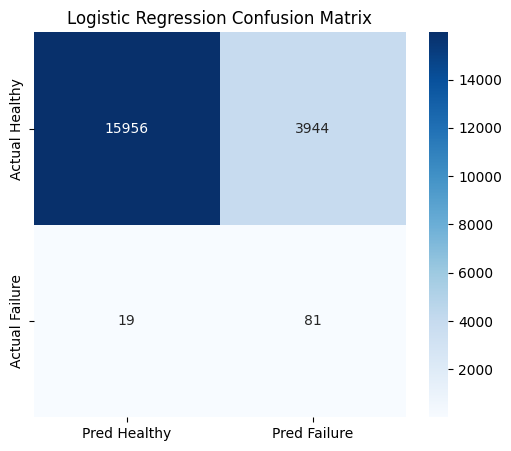

In [72]:
# =====================================
# Confusion Matrix Heatmap
# =====================================

plt.figure(figsize=(6,5))

sns.heatmap(
    cm_df,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Logistic Regression Confusion Matrix")
plt.show()

In [69]:
# =====================================
# Core Metrics
# =====================================

precision_lr = precision_score(
    y_test,
    y_pred_lr
)

recall_lr = recall_score(
    y_test,
    y_pred_lr
)

f1_lr = f1_score(
    y_test,
    y_pred_lr
)

roc_auc_lr = roc_auc_score(
    y_test,
    y_prob_lr
)

pr_auc_lr = average_precision_score(
    y_test,
    y_prob_lr
)

print(f"Precision : {precision_lr:.4f}")
print(f"Recall    : {recall_lr:.4f}")
print(f"F1 Score  : {f1_lr:.4f}")
print(f"ROC-AUC   : {roc_auc_lr:.4f}")
print(f"PR-AUC    : {pr_auc_lr:.4f}")

Precision : 0.0201
Recall    : 0.8100
F1 Score  : 0.0393
ROC-AUC   : 0.9004
PR-AUC    : 0.0954


In [70]:
# =====================================
# Metrics Summary Table
# =====================================

metrics_lr = pd.DataFrame({
    "Metric": [
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC",
        "PR-AUC"
    ],
    "Value": [
        precision_lr,
        recall_lr,
        f1_lr,
        roc_auc_lr,
        pr_auc_lr
    ]
})

metrics_lr

,Metric,Value
0,Precision,0.020124
1,Recall,0.810000
2,F1 Score,0.039273
3,ROC-AUC,0.900439
4,PR-AUC,0.095376


# Step 8: Model 2 — Random Forest + SMOTE

In [73]:
# =====================================
# Random Forest + SMOTE Imports
# =====================================

from sklearn.ensemble import RandomForestClassifier

from imblearn.over_sampling import SMOTE

In [74]:
# =====================================
# Random Forest Pipeline
# =====================================

rf_pipeline = Pipeline([
    
    ("outlier_capper", IQRCapper()),
    
    ("scaler", StandardScaler()),
    
    (
        "smote",
        SMOTE(
            random_state=RANDOM_STATE
        )
    ),
    
    (
        "model",
        RandomForestClassifier(
            n_estimators=200, 
            max_depth=10,
            random_state=RANDOM_STATE,
            n_jobs=-1
        )
    )
    
])

print(rf_pipeline)

Pipeline(steps=[('outlier_capper', IQRCapper()), ('scaler', StandardScaler()),
                ('smote', SMOTE(random_state=42)),
                ('model',
                 RandomForestClassifier(max_depth=10, n_estimators=200,
                                        n_jobs=-1, random_state=42))])


In [75]:
# =====================================
# Train Random Forest
# =====================================

rf_pipeline.fit(
    X_train,
    y_train
)

print("Random Forest Training Complete!")

Random Forest Training Complete!


In [76]:
# =====================================
# Predictions
# =====================================

y_pred_rf = rf_pipeline.predict(
    X_test
)

y_prob_rf = rf_pipeline.predict_proba(
    X_test
)[:, 1]

print("Random Forest Predictions Generated!")

Random Forest Predictions Generated!


In [77]:
print(
    "Prediction Shape:",
    y_pred_rf.shape
)

print(
    "Probability Shape:",
    y_prob_rf.shape
)

Prediction Shape: (20000,)
Probability Shape: (20000,)


# Step 9: Evaluate Random Forest

In [78]:
# =====================================
# Random Forest Classification Report
# =====================================

print(
    classification_report(
        y_test,
        y_pred_rf
    )
)

              precision    recall  f1-score   support

           0       1.00      0.97      0.99     19900
           1       0.12      0.75      0.20       100

    accuracy                           0.97     20000
   macro avg       0.56      0.86      0.59     20000
weighted avg       0.99      0.97      0.98     20000



In [79]:
# =====================================
# Confusion Matrix
# =====================================

cm_rf = confusion_matrix(
    y_test,
    y_pred_rf
)

cm_rf_df = pd.DataFrame(
    cm_rf,
    index=[
        "Actual Healthy",
        "Actual Failure"
    ],
    columns=[
        "Pred Healthy",
        "Pred Failure"
    ]
)

cm_rf_df

,Pred Healthy,Pred Failure
Actual Healthy,19340,560
Actual Failure,25,75


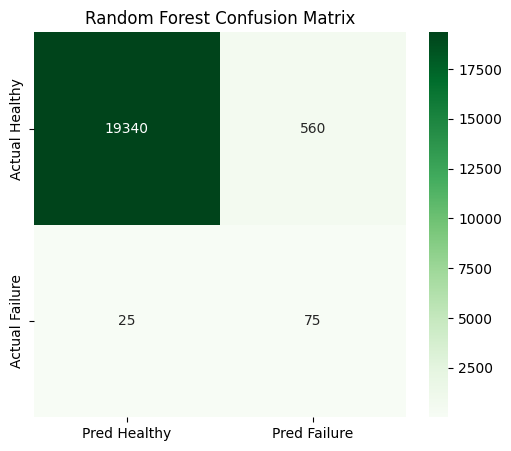

In [80]:
plt.figure(figsize=(6,5))

sns.heatmap(
    cm_rf_df,
    annot=True,
    fmt="d",
    cmap="Greens"
)

plt.title(
    "Random Forest Confusion Matrix"
)

plt.show()

In [81]:
# =====================================
# Random Forest Metrics
# =====================================

precision_rf = precision_score(
    y_test,
    y_pred_rf
)

recall_rf = recall_score(
    y_test,
    y_pred_rf
)

f1_rf = f1_score(
    y_test,
    y_pred_rf
)

roc_auc_rf = roc_auc_score(
    y_test,
    y_prob_rf
)

pr_auc_rf = average_precision_score(
    y_test,
    y_prob_rf
)

print(f"Precision : {precision_rf:.4f}")
print(f"Recall    : {recall_rf:.4f}")
print(f"F1 Score  : {f1_rf:.4f}")
print(f"ROC-AUC   : {roc_auc_rf:.4f}")
print(f"PR-AUC    : {pr_auc_rf:.4f}")

Precision : 0.1181
Recall    : 0.7500
F1 Score  : 0.2041
ROC-AUC   : 0.9781
PR-AUC    : 0.3726


## Comparison Table

In [82]:
comparison_df = pd.DataFrame({
    "Metric": [
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC",
        "PR-AUC"
    ],
    
    "Logistic Regression": [
        precision_lr,
        recall_lr,
        f1_lr,
        roc_auc_lr,
        pr_auc_lr
    ],
    
    "Random Forest": [
        precision_rf,
        recall_rf,
        f1_rf,
        roc_auc_rf,
        pr_auc_rf
    ]
})

comparison_df

,Metric,Logistic Regression,Random Forest
0,Precision,0.020124,0.118110
1,Recall,0.810000,0.750000
2,F1 Score,0.039273,0.204082
3,ROC-AUC,0.900439,0.978113
4,PR-AUC,0.095376,0.372647


# Step 10: Hyperparameter Tuning using RandomizedSearchCV

In [84]:
from sklearn.model_selection import (
    RandomizedSearchCV,
    StratifiedKFold
)

In [85]:
rf_tuning_pipeline = Pipeline([
    
    ("outlier_capper", IQRCapper()),
    
    ("scaler", StandardScaler()),
    
    (
        "smote",
        SMOTE(
            random_state=RANDOM_STATE
        )
    ),
    
    (
        "model",
        RandomForestClassifier(
            random_state=RANDOM_STATE,
            n_jobs=-1
        )
    )
])

In [86]:
param_dist = {
    
    "model__n_estimators": [
        100,
        200,
        300
    ],
    
    "model__max_depth": [
        5,
        10,
        15,
        None
    ],
    
    "model__min_samples_split": [
        2,
        5,
        10
    ],
    
    "model__min_samples_leaf": [
        1,
        2,
        4
    ]
}

In [87]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

In [88]:
random_search = RandomizedSearchCV(
    
    estimator=rf_tuning_pipeline,
    
    param_distributions=param_dist,
    
    n_iter=10,
    
    scoring="average_precision",
    
    cv=cv,
    
    verbose=2,
    
    random_state=RANDOM_STATE,
    
    n_jobs=-1
)

random_search.fit(
    X_train,
    y_train
)

Fitting 5 folds for each of 10 candidates, totalling 50 fits


,estimator,Pipeline(step...m_state=42))])
,param_distributions,"{'model__max_depth': [5, 10, ...], 'model__min_samples_leaf': [1, 2, ...], 'model__min_samples_split': [2, 5, ...], 'model__n_estimators': [100, 200, ...]}"
,n_iter,10
,scoring,'average_precision'
,n_jobs,-1
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,2
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [89]:
print("Best Parameters:")
print(random_search.best_params_)

print("\nBest Cross Validation PR-AUC:")
print(random_search.best_score_)

Best Parameters:
{'model__n_estimators': 300, 'model__min_samples_split': 5, 'model__min_samples_leaf': 2, 'model__max_depth': None}

Best Cross Validation PR-AUC:
0.6351172210639399


In [90]:
best_rf_model = random_search.best_estimator_

In [91]:
y_pred_best = best_rf_model.predict(
    X_test
)

y_prob_best = best_rf_model.predict_proba(
    X_test
)[:, 1]

In [92]:
precision_best = precision_score(
    y_test,
    y_pred_best
)

recall_best = recall_score(
    y_test,
    y_pred_best
)

f1_best = f1_score(
    y_test,
    y_pred_best
)

roc_auc_best = roc_auc_score(
    y_test,
    y_prob_best
)

pr_auc_best = average_precision_score(
    y_test,
    y_prob_best
)

print(f"Precision : {precision_best:.4f}")
print(f"Recall    : {recall_best:.4f}")
print(f"F1 Score  : {f1_best:.4f}")
print(f"ROC-AUC   : {roc_auc_best:.4f}")
print(f"PR-AUC    : {pr_auc_best:.4f}")

Precision : 0.7460
Recall    : 0.4700
F1 Score  : 0.5767
ROC-AUC   : 0.9937
PR-AUC    : 0.6222
[CV] END model__max_depth=15, model__min_samples_leaf=4, model__min_samples_split=5, model__n_estimators=300; total time= 3.1min
[CV] END model__max_depth=15, model__min_samples_leaf=1, model__min_samples_split=10, model__n_estimators=300; total time= 3.7min
[CV] END model__max_depth=15, model__min_samples_leaf=1, model__min_samples_split=10, model__n_estimators=300; total time= 3.8min
[CV] END model__max_depth=10, model__min_samples_leaf=4, model__min_samples_split=2, model__n_estimators=100; total time= 1.0min
[CV] END model__max_depth=5, model__min_samples_leaf=2, model__min_samples_split=2, model__n_estimators=300; total time= 1.9min
[CV] END model__max_depth=15, model__min_samples_leaf=4, model__min_samples_split=5, model__n_estimators=300; total time= 3.1min
[CV] END model__max_depth=None, model__min_samples_leaf=1, model__min_samples_split=2, model__n_estimators=300; total time= 4.4min

# Step 11: Threshold Optimization

In [122]:
# =====================================
# Cost-Sensitive Threshold
# =====================================

cost_sensitive_threshold = 0.01 # Based on the formula we got 0.01 -> fp/(fp+fN)

y_pred_threshold = (
    y_prob_best >= cost_sensitive_threshold
).astype(int)

print(
    f"Threshold Used: {cost_sensitive_threshold}"
)

Threshold Used: 0.01


In [123]:
print(
    classification_report(
        y_test,
        y_pred_threshold
    )
)

              precision    recall  f1-score   support

           0       1.00      0.59      0.74     19900
           1       0.01      1.00      0.02       100

    accuracy                           0.60     20000
   macro avg       0.51      0.80      0.38     20000
weighted avg       1.00      0.60      0.74     20000



In [124]:
precision_threshold = precision_score(
    y_test,
    y_pred_threshold
)

recall_threshold = recall_score(
    y_test,
    y_pred_threshold
)

f1_threshold = f1_score(
    y_test,
    y_pred_threshold
)

print(f"Precision : {precision_threshold:.4f}")
print(f"Recall    : {recall_threshold:.4f}")
print(f"F1 Score  : {f1_threshold:.4f}")

Precision : 0.0122
Recall    : 1.0000
F1 Score  : 0.0241


In [125]:
cm_threshold = confusion_matrix(
    y_test,
    y_pred_threshold
)

cm_threshold_df = pd.DataFrame(
    cm_threshold,
    index=[
        "Actual Healthy",
        "Actual Failure"
    ],
    columns=[
        "Pred Healthy",
        "Pred Failure"
    ]
)

cm_threshold_df

,Pred Healthy,Pred Failure
Actual Healthy,11807,8093
Actual Failure,0,100


In [127]:
threshold_comparison = pd.DataFrame({

    "Metric": [
        "Precision",
        "Recall",
        "F1"
    ],

    "Default Threshold (0.5)": [
        precision_best,
        recall_best,
        f1_best
    ],

    "Business Threshold (0.01)": [
        precision_threshold,
        recall_threshold,
        f1_threshold
    ]
})

threshold_comparison

,Metric,Default Threshold (0.5),Business Threshold (0.01)
0,Precision,0.746032,0.012206
1,Recall,0.470000,1.000000
2,F1,0.576687,0.024117


## Threshold Analysis Table

In [128]:
thresholds = [
    0.01,
    0.05,
    0.10,
    0.20,
    0.30,
    0.40,
    0.50,
    0.60,
    0.70,
    0.80,
    0.90
]

threshold_results = []

for threshold in thresholds:

    preds = (y_prob_best >= threshold).astype(int)

    precision = precision_score(y_test, preds, zero_division=0)
    recall = recall_score(y_test, preds, zero_division=0)
    f1 = f1_score(y_test, preds, zero_division=0)

    threshold_results.append([
        threshold,
        precision,
        recall,
        f1
    ])

threshold_df = pd.DataFrame(
    threshold_results,
    columns=[
        "Threshold",
        "Precision",
        "Recall",
        "F1 Score"
    ]
)

threshold_df

,Threshold,Precision,Recall,F1 Score
0,0.01,0.012206,1.00,0.024117
1,0.05,0.042553,1.00,0.081633
2,0.10,0.098278,0.97,0.178473
3,0.20,0.248603,0.89,0.388646
4,0.30,0.432099,0.70,0.534351
5,0.40,0.619565,0.57,0.593750
6,0.50,0.746032,0.47,0.576687
7,0.60,0.813953,0.35,0.489510
8,0.70,0.904762,0.19,0.314050
9,0.80,0.909091,0.10,0.180180


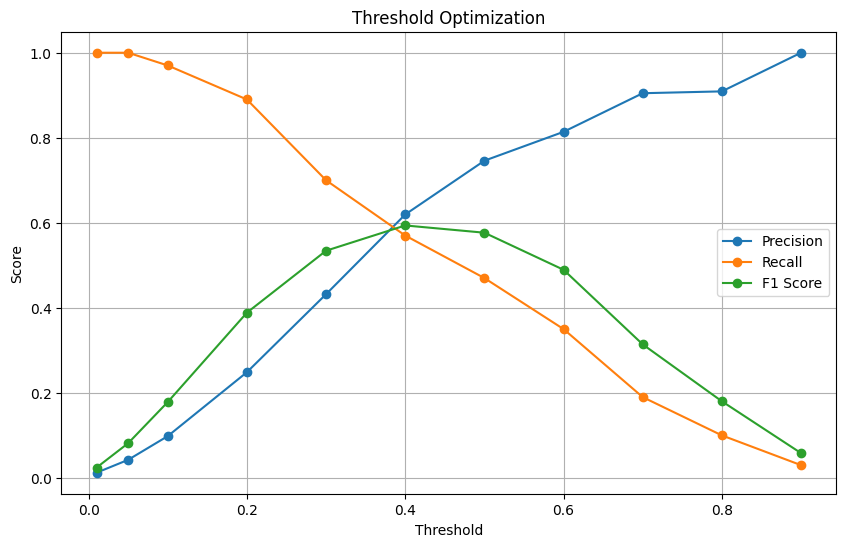

In [129]:
plt.figure(figsize=(10,6))

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Precision"],
    marker="o",
    label="Precision"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Recall"],
    marker="o",
    label="Recall"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["F1 Score"],
    marker="o",
    label="F1 Score"
)

plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Threshold Optimization")
plt.legend()
plt.grid(True)

plt.show()

In [131]:
# =====================================
# Threshold Optimization (0.25)
# =====================================

cost_sensitive_threshold = 0.25

y_pred_threshold = (
    y_prob_best >= cost_sensitive_threshold
).astype(int)

print(
    f"Threshold Used: {cost_sensitive_threshold}"
)

Threshold Used: 0.25


In [132]:
# =====================================
# Classification Report
# =====================================

from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred_threshold
    )
)

              precision    recall  f1-score   support

           0       1.00      0.99      1.00     19900
           1       0.33      0.81      0.47       100

    accuracy                           0.99     20000
   macro avg       0.66      0.90      0.73     20000
weighted avg       1.00      0.99      0.99     20000



In [133]:
# =====================================
# Precision, Recall, F1
# =====================================

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score
)

precision_threshold = precision_score(
    y_test,
    y_pred_threshold
)

recall_threshold = recall_score(
    y_test,
    y_pred_threshold
)

f1_threshold = f1_score(
    y_test,
    y_pred_threshold
)

print(f"Precision : {precision_threshold:.4f}")
print(f"Recall    : {recall_threshold:.4f}")
print(f"F1 Score  : {f1_threshold:.4f}")

Precision : 0.3279
Recall    : 0.8100
F1 Score  : 0.4669


In [134]:
# =====================================
# Confusion Matrix
# =====================================

from sklearn.metrics import confusion_matrix

cm_threshold = confusion_matrix(
    y_test,
    y_pred_threshold
)

cm_threshold_df = pd.DataFrame(
    cm_threshold,
    index=[
        "Actual Healthy",
        "Actual Failure"
    ],
    columns=[
        "Pred Healthy",
        "Pred Failure"
    ]
)

cm_threshold_df

,Pred Healthy,Pred Failure
Actual Healthy,19734,166
Actual Failure,19,81


In [136]:
# =====================================
# Threshold Comparison
# =====================================

threshold_comparison = pd.DataFrame({

    "Metric": [
        "Precision",
        "Recall",
        "F1 Score"
    ],

    "Default Threshold (0.50)": [
        precision_best,
        recall_best,
        f1_best
    ],

    "Business Threshold (0.25)": [
        precision_threshold,
        recall_threshold,
        f1_threshold
    ]
})

threshold_comparison

,Metric,Default Threshold (0.50),Business Threshold (0.25)
0,Precision,0.746032,0.327935
1,Recall,0.470000,0.810000
2,F1 Score,0.576687,0.466859


In [143]:
# Production Threshold Selection
selected_threshold = 0.25

final_precision = precision_threshold
final_recall = recall_threshold
final_f1 = f1_threshold

In [137]:
print("="*60)
print("FINAL PRODUCTION RECOMMENDATION")
print("="*60)

print("""
Selected Model:
Tuned Random Forest + SMOTE

Best Hyperparameters:
- n_estimators = 300
- min_samples_split = 5
- min_samples_leaf = 2
- max_depth = None

Recommended Threshold:
0.25

Reason:
Provides a stronger balance between Precision and Recall
compared to the default threshold while maintaining
good failure detection capability.

Evaluation Metric Focus:
PR-AUC (Average Precision)

Final Business Goal:
Detect machine failures early while minimizing
unnecessary maintenance actions.
""")

FINAL PRODUCTION RECOMMENDATION

Selected Model:
Tuned Random Forest + SMOTE

Best Hyperparameters:
- n_estimators = 300
- min_samples_split = 5
- min_samples_leaf = 2
- max_depth = None

Recommended Threshold:
0.25

Reason:
Provides a stronger balance between Precision and Recall
compared to the default threshold while maintaining
good failure detection capability.

Evaluation Metric Focus:
PR-AUC (Average Precision)

Final Business Goal:
Detect machine failures early while minimizing
unnecessary maintenance actions.



# Step 12: Final Model Comparison Table

In [144]:
final_comparison = pd.DataFrame({

    "Metric": [
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC",
        "PR-AUC"
    ],

    "Logistic Regression": [
        precision_lr,
        recall_lr,
        f1_lr,
        roc_auc_lr,
        pr_auc_lr
    ],

    "RF + SMOTE": [
        precision_rf,
        recall_rf,
        f1_rf,
        roc_auc_rf,
        pr_auc_rf
    ],

    f"Final Tuned RF + SMOTE (Threshold={selected_threshold})": [
        final_precision,
        final_recall,
        final_f1,
        roc_auc_best,
        pr_auc_best
    ]
})

final_comparison

,Metric,Logistic Regression,RF + SMOTE,Final Tuned RF + SMOTE (Threshold=0.25)
0,Precision,0.020124,0.118110,0.327935
1,Recall,0.810000,0.750000,0.810000
2,F1 Score,0.039273,0.204082,0.466859
3,ROC-AUC,0.900439,0.978113,0.993717
4,PR-AUC,0.095376,0.372647,0.622215
